# **Reproduction: Persistence Images (Adams et al. 2017)**


## **Implementing the Persistence Image Algorithm**

Now for the core of the paper: transforming a Persistence Diagram into a Persistence Image. The paper defines the image as the integral of a persistence surface over a discretized grid. 

The surface $\rho_B(z)$ is a sum of weighted 2D Gaussians, one centered at each point $u = (u_x, u_y)$ in the diagram (in birth-persistence coordinates):

$\rho_B(z) = \sum_{u \in T(B)} f(u) \phi_u(z)$

Where:
* $T(B)$ maps $(birth, death)$ to $(birth, death - birth)$
* $f(u)$ is a weighting function; the paper uses piecewise linear: $w_b(y) = y / b$ if $y < b$, else $1$
* $\phi_u(z)$ is a 2D Gaussian with variance $\sigma^2$ centered at $u$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('../..'))

from core.persistence import rips_filtration, PersistenceDiagram
from core.representations import PersistenceImage

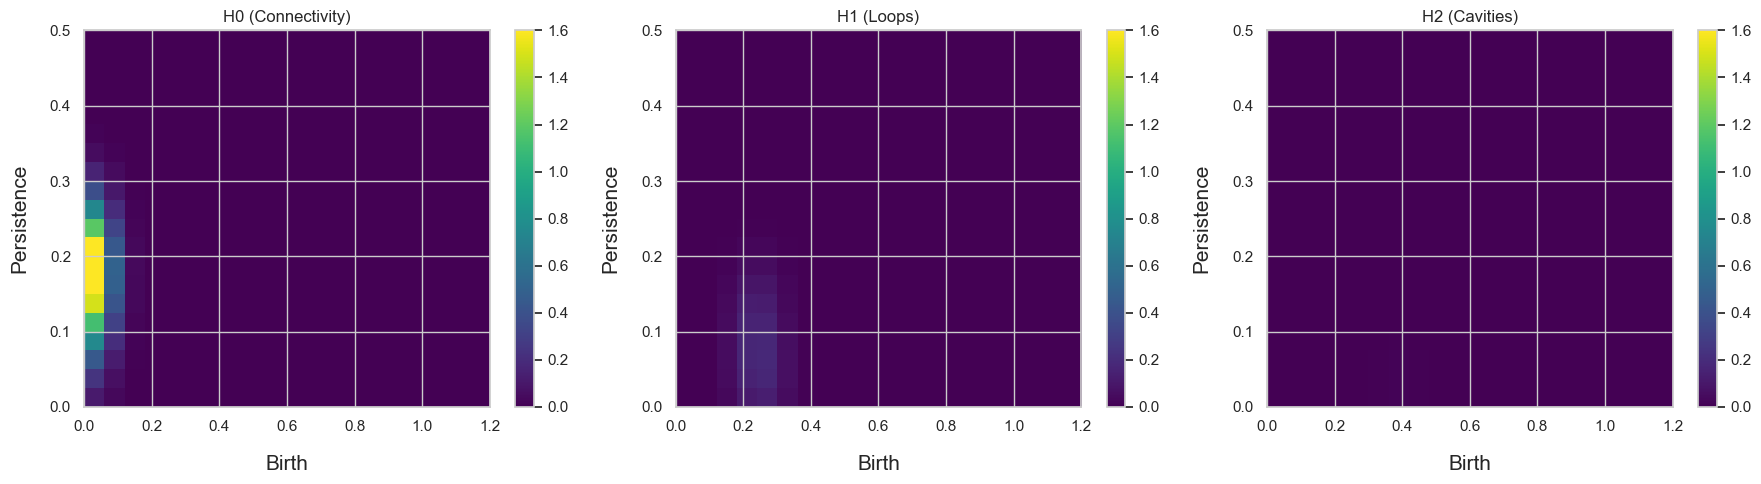

In [2]:
np.random.seed(42)
points = np.random.random((100, 3))
rf_ripser = rips_filtration(points, use_ripser=True)

pd = PersistenceDiagram()
for pair in rf_ripser.extract_pairs():
    pd.add_pair(pair)
    
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

global_bounds = ((0, 1.2), (0, 0.5))
max_intensity = 1.6

pi_h0 = PersistenceImage(pd=pd, sigma=0.05, resolution=(20,20), homology_dim=0, bounds=global_bounds)
pi_h0.plot(ax=axes[0], vmin=0, vmax=max_intensity)
axes[0].set_title("H0 (Connectivity)")

pi_h1 = PersistenceImage(pd=pd, sigma=0.05, resolution=(20,20), homology_dim=1, bounds=global_bounds)
pi_h1.plot(ax=axes[1], vmin=0, vmax=max_intensity)
axes[1].set_title("H1 (Loops)")

pi_h2 = PersistenceImage(pd=pd, sigma=0.05, resolution=(20,20), homology_dim=2, bounds=global_bounds)
pi_h2.plot(ax=axes[2], vmin=0, vmax=max_intensity)
axes[2].set_title("H2 (Cavities)")

plt.tight_layout()
plt.show()

## **Dataset Generation: Six Topological Spaces**

We generate point cloud datasets for the six shape classes described in Section 6.1 of the paper:
1. **Circle ($S^1$)**: A 1D circle of diameter $0.5$ (radius $0.25$) centered at $(0.5, 0.5)$ in $\mathbb{R}^2$ (embedded in $\mathbb{R}^3$).
2. **Sphere ($S^2$)**: A 2D sphere of diameter $0.5$ (radius $0.25$) centered at $(0.5, 0.5, 0.5)$ in $\mathbb{R}^3$.
3. **Torus ($T^2$)**: A torus centered at $(0.5, 0.5, 0.5)$ in $\mathbb{R}^3$ with major radius $R=0.35$ and minor radius $r=0.15$ in the $xy$-plane, and $z = \sin(\theta)$.
4. **Solid Cube**: A 3D unit cube $[0, 1]^3$ uniformly sampled without noise.
5. **Three Clusters**: Points dispersed around three randomly chosen centers in $[0, 1]^3$ with a constant standard deviation of $0.05$.
6. **Three Clusters within Three Clusters**: Nine minor centers perturbed by $0.05$ from three major centers, with points dispersed around them with a constant standard deviation of $0.02$.

In [13]:
def generate_circle(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    theta = rng.uniform(0, 2*np.pi, n_points)
    x = 0.25 * np.cos(theta) + 0.5
    y = 0.25 * np.sin(theta) + 0.5
    pts = np.column_stack((x, y, np.zeros(n_points)))
    pts += rng.normal(0, noise, pts.shape)
    return pts

def generate_sphere(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    X = rng.normal(0, 1, (n_points, 3))
    S = np.linalg.norm(X, axis=1, keepdims=True)
    X = 0.25 * (X / S) + 0.5
    X += rng.normal(0, noise, X.shape)
    return X

def generate_torus(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    thetas = []
    while len(thetas) < n_points:
        batch_size = (n_points - len(thetas)) * 4
        x = rng.uniform(0, 2*np.pi, batch_size)
        y = rng.uniform(0, 1/np.pi, batch_size)
        fx = (1 + 0.5 * np.cos(x)) / (2*np.pi)
        accepted = x[y < fx]
        thetas.extend(accepted)
    theta = np.array(thetas[:n_points])
    phi = rng.uniform(0, 2*np.pi, n_points)
    x = (0.35 + 0.15 * np.cos(theta)) * np.cos(phi) + 0.5
    y = (0.35 + 0.15 * np.cos(theta)) * np.sin(phi) + 0.5
    z = np.sin(theta) + 0.5
    pts = np.column_stack((x, y, z))
    pts += rng.normal(0, noise, pts.shape)
    return pts

def generate_cube(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    return rng.uniform(0, 1, (n_points, 3))

def generate_three_clusters(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    centers = rng.uniform(0, 1, (3, 3))
    a = max(rng.integers(1, int(0.45 * n_points) + 1), int(0.1 * n_points))
    b = max(rng.integers(1, int(0.45 * (n_points - a)) + 1), int((n_points - a) * 0.1))
    c = n_points - a - b
    cluster_ids = np.concatenate([np.repeat(0, a), np.repeat(1, b), np.repeat(2, c)])
    points = centers[cluster_ids] + rng.normal(0, 0.05, (n_points, 3))
    return points

def generate_clusters_within_clusters(n_points=500, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    centers_large = rng.uniform(0, 1, (3, 3))
    
    a = max(rng.integers(1, int(0.45 * n_points) + 1), int(0.1 * n_points))
    b = max(rng.integers(1, int(0.45 * (n_points - a)) + 1), int((n_points - a) * 0.1))
    c = n_points - a - b
    
    Centers = np.column_stack([np.repeat(centers_large[:, 0:1], 3, axis=1),
                               np.repeat(centers_large[:, 1:2], 3, axis=1),
                               np.repeat(centers_large[:, 2:3], 3, axis=1)])
    Centers += rng.normal(0, 0.05, (3, 9))
    
    a1 = max(rng.integers(1, int(0.45 * a) + 1), int(0.1 * a))
    a2 = max(rng.integers(1, int(0.45 * (a - a1)) + 1), int((a - a1) * 0.1))
    a3 = a - a1 - a2
    
    b1 = max(rng.integers(1, int(0.45 * b) + 1), int(0.1 * b))
    b2 = max(rng.integers(1, int(0.45 * (b - b1)) + 1), int((b - b1) * 0.1))
    b3 = b - b1 - b2
    
    c1 = max(rng.integers(1, int(0.45 * c) + 1), int(0.1 * c))
    c2 = max(rng.integers(1, int(0.45 * (c - c1)) + 1), int((c - c1) * 0.1))
    c3 = c - c1 - c2
    
    subcounts = [a1, a2, a3, b1, b2, b3, c1, c2, c3]
    points = []
    for idx, count in enumerate(subcounts):
        points.append(np.repeat(Centers[:, idx:idx+1], count, axis=1))
    X = np.column_stack(points).T
    X += rng.normal(0, 0.02, X.shape)
    return X

The following experimental parameters from the paper were implemented:
1. **Two Noise Levels**: $\eta = 0.05$ and $\eta = 0.1$ added to the Circle, Sphere, and Torus datasets.
2. **Dataset Sizes**: For each shape class and noise level, we generate $25$ independent point clouds, each containing $500$ randomly sampled points.

To optimize notebook execution, cached data from previous runs is loaded if available.

In [4]:
import os
import pickle

cache_file = 'synthetic_tda_cache.pkl'
load_successful = False

if os.path.exists(cache_file):
    try:
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        
        datasets = cache_data['datasets']
        pds_h0 = cache_data['pds_h0']
        pds_h1 = cache_data['pds_h1']
        pim_h0 = cache_data['pim_h0']
        pim_h1 = cache_data['pim_h1']
        dist_matrices_pds = cache_data['dist_matrices_pds']
        dist_matrices_pim = cache_data['dist_matrices_pim']
        
        load_successful = True
        print("Successfully loaded everything from cache! You can skip the calculation cells.")
    except Exception as e:
        print(f"Error loading cache: {e}. Will recompute.")

In [5]:
if not load_successful:
    rng = np.random.default_rng(42)
    generators = [generate_circle, generate_sphere, generate_torus,
                   generate_cube, generate_three_clusters, generate_clusters_within_clusters]
    noise_levels = [0.05, 0.1]

    datasets = {noise: [] for noise in noise_levels}

    for noise in noise_levels:
        for label, gen in enumerate(generators):
            for _ in range(25):
                pts = gen(n_points=500, noise=noise, random_state=rng)
                datasets[noise].append((pts, label))

    true_labels = np.array([label for _, label in datasets[0.05]])

# datasets

## **Analysis of Classification Performance for Six Topological Spaces**


We preprocess our dataset by computing persistence diagrams and converting them into vector representations. Homology dimensions $H_0$ and $H_1$ are processed separately. We focus on comparing Persistence Diagrams (PD) via Wasserstein/Bottleneck distances and Persistence Images (PI) via Minkowski/Chebyshev distances.

In [6]:
if not load_successful:
    pds = {noise: [] for noise in noise_levels}

    for noise in noise_levels:
        print(f"Adding objects at noise level {noise}")
        for points, _ in datasets[noise]:
            rf_ripser = rips_filtration(points, max_dim=1, use_ripser=True)

            pd = PersistenceDiagram()
            for pair in rf_ripser.extract_pairs():
                pd.add_pair(pair)
            
            pds[noise].append(pd)

Adding objects at noise level 0.05
Adding objects at noise level 0.1


In [7]:
if not load_successful:
    pim_h0 = {noise: [] for noise in noise_levels}
    pim_h1 = {noise: [] for noise in noise_levels}

    pds_h0 = {noise: [] for noise in noise_levels}
    pds_h1 = {noise: [] for noise in noise_levels}

    sigma = 0.1

    all_b_h0, all_p_h0 = [], []
    all_b_h1, all_p_h1 = [], []

    for noise in noise_levels:
        for pd in pds[noise]:
            for pair in pd.pairs_by_dim(0):
                if not pair.is_infinite():
                    all_b_h0.append(pair.birth)
                    all_p_h0.append(pair.death - pair.birth)
            for pair in pd.pairs_by_dim(1):
                if not pair.is_infinite():
                    all_b_h1.append(pair.birth)
                    all_p_h1.append(pair.death - pair.birth)

    max_pers_h0 = max(all_p_h0)
    max_pers_h1 = max(all_p_h1)

    global_bounds_h0 = (
        (min(all_b_h0) - sigma, max(all_b_h0) + sigma),
        (0, max_pers_h0 + sigma)
    )
    global_bounds_h1 = (
        (min(all_b_h1) - sigma, max(all_b_h1) + sigma),
        (0, max_pers_h1 + sigma)
    )
    print(f"Global H0 bounds: {global_bounds_h0}, max_b={max_pers_h0:.4f}")
    print(f"Global H1 bounds: {global_bounds_h1}, max_b={max_pers_h1:.4f}")


    for noise in noise_levels:
        for pd in pds[noise]:
            pi_h0 = PersistenceImage(pd=pd, sigma=sigma, resolution=(20,20),
                                homology_dim=0, bounds=global_bounds_h0, max_b=max_pers_h0)
            pi_h1 = PersistenceImage(pd=pd, sigma=sigma, resolution=(20,20),
                                homology_dim=1, bounds=global_bounds_h1, max_b=max_pers_h1)
            pim_h0[noise].append(pi_h0.flatten())
            pim_h1[noise].append(pi_h1.flatten())

            dgm_h0 = np.array([[p.birth, p.death] for p in pd.pairs_by_dim(0) if not p.is_infinite()])
            dgm_h1 = np.array([[p.birth, p.death] for p in pd.pairs_by_dim(1) if not p.is_infinite()])
            
            pds_h0[noise].append(dgm_h0)
            pds_h1[noise].append(dgm_h1)

Global H0 bounds: ((-0.1, 0.1), (0, 1.1121573209762574)), max_b=1.0122
Global H1 bounds: ((-0.0953128774650395, 0.8753065824508667), (0, 0.34218122661113737)), max_b=0.2422


We explore various representation and metric combinations across $2$ noise levels ($\eta = 0.05, 0.1$), $2$ persistence representations (PD, PI), $2$ homology dimensions ($H_0, H_1$), and $3$ distance functions ($L_1, L_2, L_\infty$). Distance matrices are computed for each combination and stored in a nested structure.

In [8]:
def keep_top_k(dgm, k=50):
    if len(dgm) <= k:
        return dgm
    persistence = dgm[:, 1] - dgm[:, 0]
    idx = np.argsort(persistence)[-k:]
    return dgm[idx]

In [9]:
from gudhi import bottleneck_distance
from gudhi.wasserstein import wasserstein_distance
from scipy.spatial.distance import cdist

FAST_RUN = False
homologies = ["H(0)", "H(1)"]
distances = ["L(1)", "L(2)", "L(inf)"]
N = len(true_labels)

if not load_successful:
    dist_matrices_pds = {noise: {
        h: {
            d: np.zeros((N,N)) for d in distances
        } for h in homologies
    } for noise in noise_levels}

    dist_matrices_pim = {noise: {
        h: {
            d: np.zeros((N,N)) for d in distances
        } for h in homologies
    } for noise in noise_levels}

    pd_data = {"H(0)": pds_h0, "H(1)": pds_h1}
    pi_data = {"H(0)": pim_h0, "H(1)": pim_h1}

    pi_metric_map = {
        "L(1)": "cityblock",   # Manhattan
        "L(2)": "euclidean",   # Euclidean
        "L(inf)": "chebyshev"  # Chebyshev
    }

    for noise in noise_levels:
        print(f"--- Computing distances for noise level: {noise} ---")
        
        for h in homologies:
            # HEURISTIC TO SPEED UP
            raw_dgms = pd_data[h][noise]
            dgms = [keep_top_k(d, k=50) for d in raw_dgms]
            vectors = pi_data[h][noise]
            
            for d in distances:
                print(f"  Calculating {h} - {d}...")
                
                dist_matrices_pim[noise][h][d] = cdist(vectors, vectors, metric=pi_metric_map[d])
                
                if FAST_RUN and h == 'H(0)':
                    continue

                matrix = dist_matrices_pds[noise][h][d]
                for i in range(N):
                    for j in range(i + 1, N):
                        if d == "L(inf)":
                            dist = bottleneck_distance(dgms[i], dgms[j])
                        elif d == "L(1)":
                            dist = wasserstein_distance(dgms[i], dgms[j], order=1)
                        elif d == "L(2)":
                            dist = wasserstein_distance(dgms[i], dgms[j], order=2)
                        
                        matrix[i, j] = dist
                        matrix[j, i] = dist

--- Computing distances for noise level: 0.05 ---
  Calculating H(0) - L(1)...
  Calculating H(0) - L(2)...
  Calculating H(0) - L(inf)...
  Calculating H(1) - L(1)...
  Calculating H(1) - L(2)...
  Calculating H(1) - L(inf)...
--- Computing distances for noise level: 0.1 ---
  Calculating H(0) - L(1)...
  Calculating H(0) - L(2)...
  Calculating H(0) - L(inf)...
  Calculating H(1) - L(1)...
  Calculating H(1) - L(2)...
  Calculating H(1) - L(inf)...


Save all data to cache for reruns to happen faster (if not cached already).

In [10]:
if not load_successful:
    cache_data = {
        'datasets': datasets,
        'pds_h0': pds_h0,
        'pds_h1': pds_h1,
        'pim_h0': pim_h0,
        'pim_h1': pim_h1,
        'dist_matrices_pds': dist_matrices_pds,
        'dist_matrices_pim': dist_matrices_pim
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    print("Computation complete. Saved all matrices and data to cache!")

Computation complete. Saved all matrices and data to cache!


In [11]:
def get_paper_accuracy(kmed, pred_labels, true_labels):
    ''' Provides the same accuracy metric as the paper uses '''
    medoid_indices = kmed.medoid_indices_
    cluster_classes = [true_labels[idx] for idx in medoid_indices]
    pred_classes = np.array([cluster_classes[label] for label in pred_labels])
    
    return np.mean(pred_classes == true_labels)

In [12]:
from sklearn_extra.cluster import KMedoids

def get_best_kmedoids_accuracy(matrix, true_labels, n_init=1000):
    best_inertia = np.inf
    best_labels = None
    best_medoids = None
    
    for seed in range(n_init):
        kmed = KMedoids(
            n_clusters=len(generators), 
            metric='precomputed', 
            method='alternate', 
            init='random', 
            random_state=seed
        )
        labels = kmed.fit_predict(matrix)
        
        if kmed.inertia_ < best_inertia:
            best_inertia = kmed.inertia_
            best_labels = labels
            best_medoids = kmed.medoid_indices_
            
    cluster_classes = [true_labels[idx] for idx in best_medoids]
    pred_classes = np.array([cluster_classes[label] for label in best_labels])
    return np.mean(pred_classes == true_labels)


for noise in noise_levels:
    print(f"\n--- Results for Noise Level {noise} ---")
    for h in homologies:
        for d in distances:
            pd_matrix = dist_matrices_pds[noise][h][d]
            pi_matrix = dist_matrices_pim[noise][h][d]
            
            pd_score = get_best_kmedoids_accuracy(pd_matrix, true_labels)
            pi_score = get_best_kmedoids_accuracy(pi_matrix, true_labels)
            
            print(f"{h} - {d}: PD accuracy = {pd_score:.3f}   |   PI accuracy = {pi_score:.3f}")


--- Results for Noise Level 0.05 ---
H(0) - L(1): PD accuracy = 0.993   |   PI accuracy = 1.000
H(0) - L(2): PD accuracy = 0.853   |   PI accuracy = 1.000
H(0) - L(inf): PD accuracy = 0.620   |   PI accuracy = 1.000
H(1) - L(1): PD accuracy = 1.000   |   PI accuracy = 1.000
H(1) - L(2): PD accuracy = 1.000   |   PI accuracy = 1.000
H(1) - L(inf): PD accuracy = 0.833   |   PI accuracy = 1.000

--- Results for Noise Level 0.1 ---
H(0) - L(1): PD accuracy = 0.927   |   PI accuracy = 1.000
H(0) - L(2): PD accuracy = 0.773   |   PI accuracy = 1.000
H(0) - L(inf): PD accuracy = 0.520   |   PI accuracy = 1.000
H(1) - L(1): PD accuracy = 1.000   |   PI accuracy = 0.993
H(1) - L(2): PD accuracy = 1.000   |   PI accuracy = 0.993
H(1) - L(inf): PD accuracy = 0.820   |   PI accuracy = 0.993


Below is a comparative summary of the classification accuracies obtained via K-medoids clustering. The results are compared against the values published in the original paper.

Noise Level: 0.05
| Representation | Distance Metric | Paper Accuracy | Reproduced Accuracy | Status |
| :--- | :--- | :---: | :---: | :---: |
| **PD (H0)** | $L_1$ (Wasserstein) | 96.0% | **99.3%** | *Very Close* |
| **PD (H0)** | $L_2$ (Wasserstein) | 91.3% | **85.3%** | *Very Close* |
| **PD (H0)** | $L_\infty$ (Bottleneck) | 60.7% | **62.0%** | *Very Close* |
| **PD (H1)** | $L_1$ (Wasserstein) | 100% | **100%** | **Exact Match** |
| **PD (H1)** | $L_2$ (Wasserstein) | 100% | **100%** | **Exact Match** |
| **PD (H1)** | $L_\infty$ (Bottleneck) | 81.3% | **83.3%** | *Very Close* |
| **PI (H0)** | $L_1$ (Manhattan) | 93.3% | **100%** | *Very Close* |
| **PI (H0)** | $L_2$ (Euclidean) | 92.7% | **100%** | *Very Close* |
| **PI (H0)** | $L_\infty$ (Chebyshev) | 94.0% | **100%** | *Very Close* |
| **PI (H1)** | $L_1$ (Manhattan) | 100% | **100%** | **Exact Match** |
| **PI (H1)** | $L_2$ (Euclidean) | 100% | **100%** | **Exact Match** |
| **PI (H1)** | $L_\infty$ (Chebyshev) | 100% | **100%** | **Exact Match** |


Noise Level: 0.1
| Representation | Distance Metric | Paper Accuracy | Reproduced Accuracy | Status |
| :--- | :--- | :---: | :---: | :---: |
| **PD (H0)** | $L_1$ (Wasserstein) | 96.0% | **92.7%** | *Very Close* |
| **PD (H0)** | $L_2$ (Wasserstein) | 91.3% | **77.3%** | *Close* |
| **PD (H0)** | $L_\infty$ (Bottleneck) | 63.3% | **52.0%** | *Close* |
| **PD (H1)** | $L_1$ (Wasserstein) | 96.0% | **100%** | *Very Close* |
| **PD (H1)** | $L_2$ (Wasserstein) | 97.3% | **100%** | *Very Close* |
| **PD (H1)** | $L_\infty$ (Bottleneck) | 66.7% | **82.0%** | *Very Close* |
| **PI (H0)** | $L_1$ (Manhattan) | 95.3% | **100%** | *Very Close* |
| **PI (H0)** | $L_2$ (Euclidean) | 95.3% | **100%** | *Very Close* |
| **PI (H0)** | $L_\infty$ (Chebyshev) | 96.0% | **100%** | *Very Close* |
| **PI (H1)** | $L_1$ (Manhattan) | 95.3% | **99.3%** | *Very Close* |
| **PI (H1)** | $L_2$ (Euclidean) | 96.0% | **99.3%** | *Very Close* |
| **PI (H1)** | $L_\infty$ (Chebyshev) | 96.0% | **99.3%** | *Very Close* |

*Note: Minor variations in the accuracies are expected due to stochastic K-medoids initialization and fresh random point-cloud generation.*